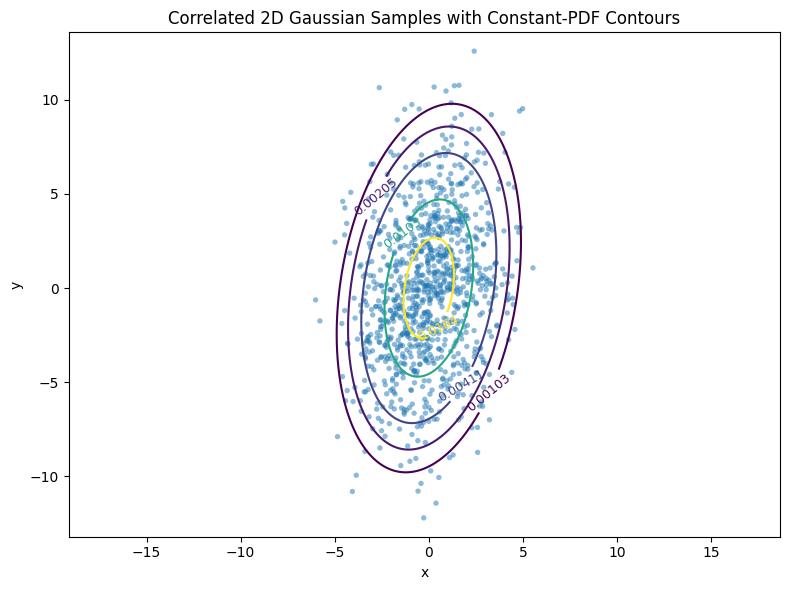

Sample correlation coefficient: 0.23516537914768165


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# 1) Generate correlated 2D Gaussian samples
N = 1000
mu = np.array([0.0, 0.0])
Sigma = np.array([[4.0, 2.0],
                  [2.0, 16.0]])

samples = np.random.multivariate_normal(mean=mu, cov=Sigma, size=N)
x = samples[:, 0]
y = samples[:, 1]

# 2) Compute the 2D Gaussian PDF on a grid for contour plotting
Sigma_inv = np.linalg.inv(Sigma)
det_Sigma = np.linalg.det(Sigma)

pad = 1.0
xmin, xmax = x.min() - pad, x.max() + pad
ymin, ymax = y.min() - pad, y.max() + pad

grid_n = 250
X, Y = np.meshgrid(np.linspace(xmin, xmax, grid_n),
                   np.linspace(ymin, ymax, grid_n))

DX = X - mu[0]
DY = Y - mu[1]

# Mahalanobis distance squared: (z-μ)^T Σ^{-1} (z-μ)
Q = (Sigma_inv[0, 0] * DX**2
     + 2.0 * Sigma_inv[0, 1] * DX * DY
     + Sigma_inv[1, 1] * DY**2)

norm_const = 1.0 / (2.0 * np.pi * np.sqrt(det_Sigma))
PDF = norm_const * np.exp(-0.5 * Q)

# 3) Plot scatter + constant-PDF contours
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=15, alpha=0.5, edgecolor="none")

peak = float(PDF.max())

# Make levels strictly increasing and safely within (min, max]
fractions = np.array([0.05, 0.10, 0.20, 0.50, 0.80])  # increasing
levels = peak * fractions

cs = plt.contour(X, Y, PDF, levels=levels)
plt.clabel(cs, inline=True, fontsize=9, fmt="%.3g")

plt.title("Correlated 2D Gaussian Samples with Constant-PDF Contours")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.tight_layout()
plt.show()

print("Sample correlation coefficient:", np.corrcoef(x, y)[0, 1])


A real-world example of two observables with this kind of positive correlation is height and weight in an adult population (taller people tend to weigh more, with spread around the trend).